In [112]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [113]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [114]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,unemployment_rate,median_income,white_share,non_white_share
0,BALDWIN,207643,122542,0.5902,0.0634,253507.0,10.0,8.268600,32.797637,2.3,71704.0,0.922164,0.077836
1,BARBOUR,17666,9919,0.5615,0.0598,24585.0,25.5,22.186295,11.464715,4.4,41151.0,0.603878,0.396122
2,BULLOCK,7181,4144,0.5771,0.0980,9897.0,33.6,25.955544,8.999729,2.4,35798.0,0.267722,0.732278
3,BUTLER,14530,8530,0.5871,0.0544,18382.0,23.6,12.405044,13.764813,2.9,41852.0,0.618713,0.381287
4,CHOCTAW,10767,6692,0.6215,0.0675,12252.0,24.8,15.781285,13.914203,4.0,44458.0,0.629044,0.370956


In [115]:
candidate_features = [
    "poverty_rate",
    "unemployment_rate",
    "median_income",
    "pct_less_hs",
    "non_white_share"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share
0,10.0,2.3,71704.0,8.268600,0.077836
1,25.5,4.4,41151.0,22.186295,0.396122
2,33.6,2.4,35798.0,25.955544,0.732278
3,23.6,2.9,41852.0,12.405044,0.381287
4,24.8,4.0,44458.0,15.781285,0.370956


In [116]:
pca_df.describe()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share
count,24.000000,22.000000,22.000000,24.000000,25.000000
mean,24.416667,3.600000,44320.318182,15.467159,0.475974
std,6.375747,0.937575,9003.479605,4.094101,0.201852
min,10.000000,2.300000,33585.000000,8.268600,0.077836
25%,19.075000,2.825000,36229.750000,12.414252,0.348480
50%,23.700000,3.300000,44580.000000,15.256294,0.405595
75%,29.800000,4.375000,47020.250000,17.557432,0.669784
max,33.800000,5.400000,71704.000000,25.955544,0.793572


In [117]:
# poverty: higher poverty = higher risk
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

# unemployment: higher unemployment = higher risk
if pca_df["unemployment_rate"].max() > 1:
    pca_df["unemployment_rate"] = pca_df["unemployment_rate"] / 100

# education: higher % less than HS = higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

# income: higher income = lower risk
pca_df["median_income"] = -1 * pca_df["median_income"]

pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share
0,0.100,0.023,-71704.0,0.082686,0.077836
1,0.255,0.044,-41151.0,0.221863,0.396122
2,0.336,0.024,-35798.0,0.259555,0.732278
3,0.236,0.029,-41852.0,0.124050,0.381287
4,0.248,0.040,-44458.0,0.157813,0.370956


In [118]:
pca_df.isna().sum()

poverty_rate         1
unemployment_rate    3
median_income        3
pct_less_hs          1
non_white_share      0
dtype: int64

In [119]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share
0,0.100,0.023,-71704.0,0.082686,0.077836
1,0.255,0.044,-41151.0,0.221863,0.396122
2,0.336,0.024,-35798.0,0.259555,0.732278
3,0.236,0.029,-41852.0,0.124050,0.381287
4,0.248,0.040,-44458.0,0.157813,0.370956


In [120]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [121]:
corr = X_imputed.corr()
corr

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share
poverty_rate,1.000000,0.428116,0.863544,0.554505,0.803671
unemployment_rate,0.428116,1.000000,0.517906,0.194802,0.394743
median_income,0.863544,0.517906,1.000000,0.499873,0.667778
pct_less_hs,0.554505,0.194802,0.499873,1.000000,0.399344
non_white_share,0.803671,0.394743,0.667778,0.399344,1.000000


In [122]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [123]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.641953,0.641953
1,PC2,0.163016,0.804969
2,PC3,0.114887,0.919856
3,PC4,0.061067,0.980923
4,PC5,0.019077,1.000000


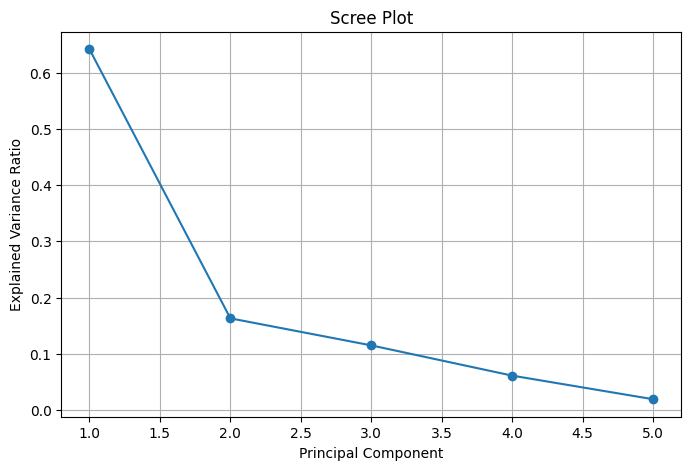

In [124]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

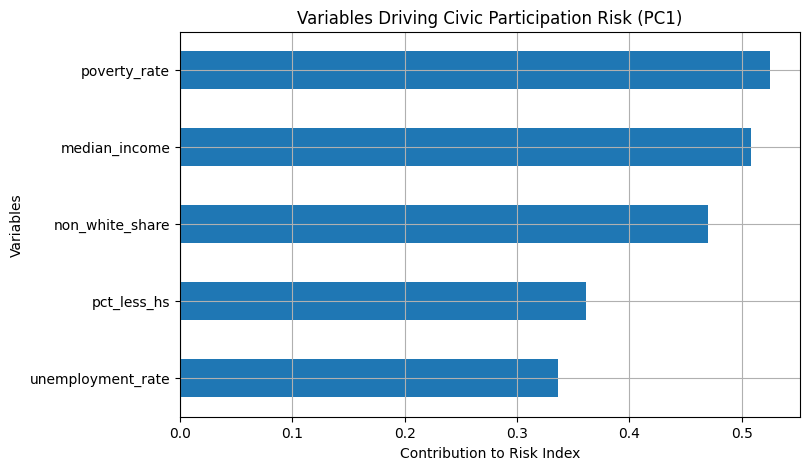

In [130]:
# PC1 Loadings Bar Chart

plt.figure(figsize=(8, 5))

# Sort values for cleaner visualization
loadings["PC1"].sort_values().plot(kind="barh")

plt.title("Variables Driving Civic Participation Risk (PC1)")
plt.xlabel("Contribution to Risk Index")
plt.ylabel("Variables")

plt.grid(True)

plt.show()

In [125]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5
poverty_rate,0.525649,-0.102207,-0.242703,0.199488,0.783930
unemployment_rate,0.336845,0.764892,0.503708,-0.202797,0.081413
median_income,0.508268,0.050103,-0.057994,0.678449,-0.524878
pct_less_hs,0.361562,-0.634022,0.642488,-0.222873,-0.069473
non_white_share,0.470282,-0.000324,-0.520788,-0.639619,-0.313850


In [126]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-5.022101
1,BARBOUR,1.047811
2,BULLOCK,2.440926
3,BUTLER,-0.678694
4,CHOCTAW,-0.021359


In [127]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,BARBOUR,77.526872
2,BULLOCK,95.320192
3,BUTLER,55.475393
4,CHOCTAW,63.871094


In [128]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
18,PERRY,100.000000
10,GREENE,97.180042
2,BULLOCK,95.320192
8,DALLAS,91.053438
23,WILCOX,85.314905
21,SUMTER,85.157067
12,LOWNDES,84.577808
13,MACON,83.079283
1,BARBOUR,77.526872
6,CONECUH,67.019371


In [129]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)